# Analiza Głównych Składowych (PCA)

**Cel:** Redukcja wymiarowości danych (usunięcie szumu i redundancji) przy jednoczesnym zachowaniu jak największej ilości informacji o spółkach.

### Krok 1: Wczytanie i ostateczne czyszczenie danych
Wczytujemy nasz przygotowany plik `aggregated_company_data.csv`. Ponieważ PCA operuje wyłącznie na liczbach i nie toleruje braków danych (NaN), stosujemy imputację: puste wartości wypełniamy zerem, co w przypadku naszych **ustandaryzowanych danych** oznacza po prostu przypisanie danej spółce rynkowej średniej. Usuwamy również z analizy kolumny kategoryczne/identyfikatory.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

LOCAL_FOLDER = Path.cwd().parent / "local_folder"
df_pca = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')

df_pca = df_pca.replace([np.inf, -np.inf], np.nan)
df_pca = df_pca.fillna(0)


### Krok 2: Eliminacja kolumn, które dublują informacje o waiancji
Np. Revenue_WMA, Revenue_std, Revenue_cv, Revenue_slope są wyliczane z tej samej agregogowanej kolumny "Revenue"

Za pomocą PCAnalysis wybieramy, która z tych czterech metryk opisuje najwięcej wariancji w danej Składowej Głównej X (PCx)

In [2]:
names_tuple = ('_WMA', '_std', '_cv', '_slope')
doubled_columns = [col for col in df_pca.columns if col.endswith(names_tuple)]

double_col_df = df_pca[doubled_columns]

pca_1 = PCA()
pca_1.fit(double_col_df)

explained_variance = pca_1.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Składowa': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Wariancja (%)': explained_variance,
    'Skumulowana wariancja (%)': cumulative_variance
})

print("Tabela Wariancji Wyjaśnionej dla kolumn WMA, STD, CV, SLOPE:")
display(pca_summary.round(2))

Tabela Wariancji Wyjaśnionej dla kolumn WMA, STD, CV, SLOPE:


,Składowa,Wariancja (%),Skumulowana wariancja (%)
0,PC1,27.02,27.02
1,PC2,13.19,40.21
2,PC3,8.19,48.40
3,PC4,7.69,56.09
4,PC5,6.63,62.72
5,PC6,5.79,68.51
6,PC7,5.15,73.66
7,PC8,4.87,78.54
8,PC9,4.27,82.81
9,PC10,3.90,86.71


### Krok 3: Heatmapa dla metryk doublujących się

Tabela **Ładunków (Loading_scores)** pokazuje wpływ (od -1 do 1) oryginalnych metryk na nowe Składowe. Jeśli jakaś zmienna ma dużą wartość bezwzględną (np. 0.8 lub -0.7) w kolumnie PC1, oznacza to, że PC1 w dużej mierze reprezentuje właśnie tę oryginalną metrykę. Generujemy heatmapę dla graficznej wizualizacji.

Na podstawie tej heatmapy decyzdujemy, która z pośród czterech statystyk dla danej matryki podstawowej niesie najwięcej informacji o wariancji 

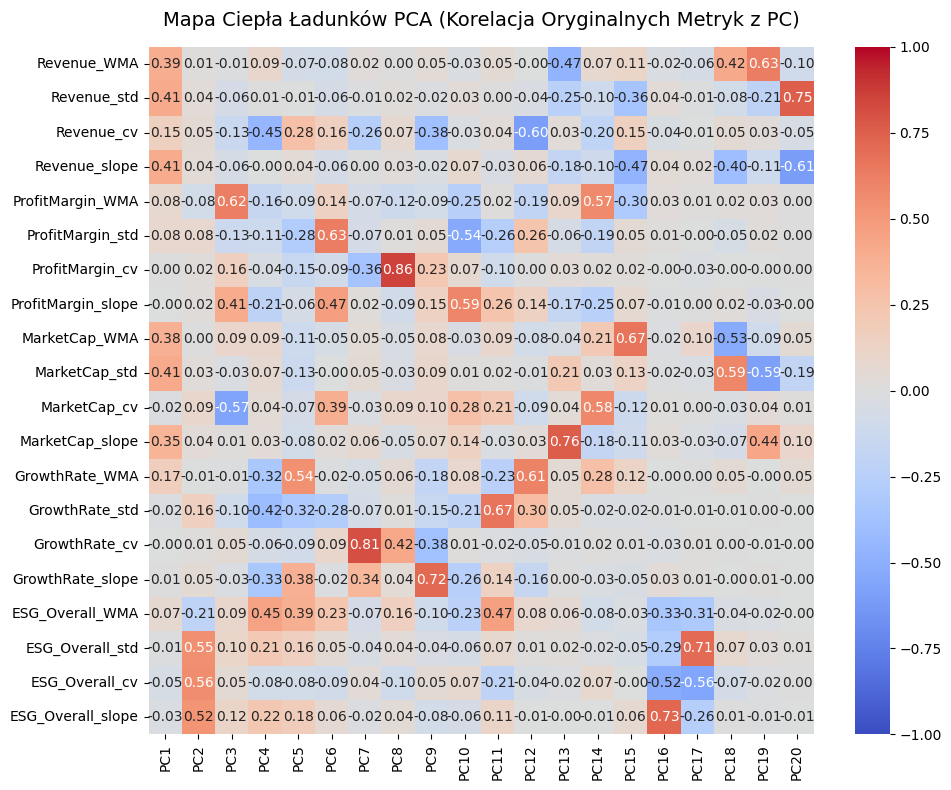

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
Revenue_WMA,0.394882,0.010092,-0.011528,0.089895,-0.072547,-0.082256,0.024467,0.003830,0.045183,-0.026950,0.047025,-0.001243,-0.470066,0.073101,0.109144,-0.023941,-0.059917,0.417805,0.626166,-0.095406
Revenue_std,0.410772,0.035351,-0.062819,0.007484,-0.007471,-0.059295,-0.008755,0.020664,-0.020489,0.033027,0.002733,-0.038600,-0.248848,-0.104980,-0.358436,0.035052,-0.010752,-0.078808,-0.212338,0.751576
Revenue_cv,0.153740,0.052207,-0.133989,-0.446866,0.280479,0.162564,-0.258517,0.068506,-0.384222,-0.025095,0.035410,-0.598401,0.033436,-0.201748,0.149179,-0.039483,-0.007648,0.048215,0.030332,-0.053354
Revenue_slope,0.405020,0.040511,-0.061971,-0.001095,0.041175,-0.063579,0.000130,0.025413,-0.024216,0.073365,-0.033108,0.058384,-0.179255,-0.104544,-0.470144,0.044741,0.024561,-0.404947,-0.112171,-0.608566
ProfitMargin_WMA,0.077873,-0.079024,0.618166,-0.157372,-0.094773,0.138444,-0.067258,-0.117394,-0.085172,-0.251372,0.015330,-0.193772,0.089206,0.570733,-0.300438,0.026059,0.008085,0.022469,0.030161,0.001283
ProfitMargin_std,0.078249,0.081367,-0.132781,-0.113612,-0.284499,0.632800,-0.067442,0.008210,0.049057,-0.536661,-0.261706,0.255617,-0.057884,-0.193725,0.048730,0.012358,-0.004705,-0.052778,0.015980,0.003876
ProfitMargin_cv,0.004683,0.019041,0.163431,-0.039817,-0.150572,-0.088029,-0.364866,0.858949,0.229700,0.069115,-0.099316,0.002208,0.034049,0.017732,0.019381,-0.002738,-0.026580,-0.002479,-0.001554,0.000035
ProfitMargin_slope,-0.004734,0.019058,0.405770,-0.214109,-0.055324,0.471345,0.019776,-0.088161,0.147996,0.593438,0.256891,0.139847,-0.170428,-0.246169,0.069010,-0.010333,0.003067,0.020850,-0.033769,-0.003497
MarketCap_WMA,0.381173,0.004774,0.093814,0.086251,-0.112292,-0.054224,0.046631,-0.046716,0.081262,-0.034127,0.086763,-0.084027,-0.044858,0.212826,0.670811,-0.021418,0.097068,-0.526897,-0.094724,0.049116
MarketCap_std,0.407976,0.028764,-0.026957,0.069448,-0.129900,-0.004447,0.047631,-0.032794,0.090424,0.008089,0.015421,-0.012230,0.213853,0.030198,0.127064,-0.015403,-0.029405,0.593586,-0.586985,-0.193710


In [3]:
num_components_to_analyze = len(explained_variance)

loadings = pd.DataFrame(
    pca_1.components_.T[:, :num_components_to_analyze], 
    columns=[f'PC{i+1}' for i in range(num_components_to_analyze)],
    index=double_col_df.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Mapa Ciepła Ładunków PCA (Korelacja Oryginalnych Metryk z PC)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

display(loadings)

### Krok 4: Ranking metryk dla Revenue, ProfitMargin, MarketCap, GrowthRate, ESG
Na podstawie wyników z poprzedniego kroku wstawiamy wyniki do wzoru:

#### PCA-based Feature Importance (Ważone Ładunki Absolutne)

Aby wyłonić najważniejsze metryki z modelu PCA, obliczamy ich globalną istotność, ważąc bezwzględne wartości ładunków (loading scores) procentowym udziałem danego komponentu w wyjaśnianiu wariancji. Metoda ta pozwala wyłonić cechy, które niosą najwięcej unikalnych informacji o całym zbiorze danych.

$$I_j = \sum_{i=1}^{k} \lambda_i |l_{i,j}|$$

**Wyjaśnienie zmiennych:**
*   $I_j$ – Ostateczna istotność (waga) oryginalnej cechy (metryki) $j$. Im wyższa wartość, tym metryka silniej różnicuje analizowany rynek.
*   $k$ – Liczba uwzględnianych głównych składowych (PC), najczęściej dobierana tak, aby pokryć optymalny próg skumulowanej wariancji (np. 75%).
*   $\lambda_i$ – Procent całkowitej wariancji wyjaśnianej przez składową $i$. Stanowi wagę ważności danego komponentu (w bibliotece `scikit-learn` jest to wartość z `pca.explained_variance_ratio_`).
*   $l_{i,j}$ – Ładunek (loading score) cechy $j$ w składowej $i$. Określa siłę korelacji metryki z danym komponentem, stąd zastosowanie wartości bezwzględnej (w `scikit-learn` pobierany z macierzy `pca.components_`).

In [ ]:
weighted_importance = np.dot(pca_1.explained_variance_ratio_, np.abs(pca_1.components_))

feature_importance_df = pd.DataFrame({
    'Metryka': double_col_df.columns,
    'Istotnosc_PCA': weighted_importance
}).sort_values(by='Istotnosc_PCA', ascending=False)

display(feature_importance_df)

,Metryka,Istotnosc_PCA
2,Revenue_cv,0.178634
16,ESG_Overall_WMA,0.178599
8,MarketCap_WMA,0.159159
12,GrowthRate_WMA,0.157657
13,GrowthRate_std,0.156852
5,ProfitMargin_std,0.155602
4,ProfitMargin_WMA,0.154167
11,MarketCap_slope,0.149694
9,MarketCap_std,0.149465
3,Revenue_slope,0.148247


### Krok 5: Wybór metryk na podstawie rankingu

In [11]:
regular_metrics_columns = []
prefix_controller = []

for col in feature_importance_df['Metryka']:
    prefix = str.split(col, '_')[0]

    if prefix not in prefix_controller:
        regular_metrics_columns.append(col)
        prefix_controller.append(prefix)

for col in regular_metrics_columns:
    print(col)

Revenue_cv
ESG_Overall_WMA
MarketCap_WMA
GrowthRate_WMA
ProfitMargin_std


### Krok 6: Definiujemy sztywną listę konkretnych metryk
Na podstawie outputu w poprzednim korku

In [12]:
calculated_metrics_columns = [
    'PriceToSales', 
    'NetIncome', 
    'PriceToEarnings', 
    'EarningsYield',
    'Risk-AdjustedGrowth', 
    'Earnings-to-Growth', 
    'ESG_Signal-to-Noise'
]

final_columns = regular_metrics_columns + calculated_metrics_columns


# Z ORYGINALNEJ TABELI zostawiamy tylko te metryki 

X = df_pca[final_columns]

print(f"Dane gotowe do PCA. Liczba wierszy: {X.shape[0]}, Liczba analizowanych metryk: {X.shape[1]}")
display(X.head())

Dane gotowe do PCA. Liczba wierszy: 1000, Liczba analizowanych metryk: 12


,Revenue_cv,ESG_Overall_WMA,MarketCap_WMA,GrowthRate_WMA,ProfitMargin_std,PriceToSales,NetIncome,PriceToEarnings,EarningsYield,Risk-AdjustedGrowth,Earnings-to-Growth,ESG_Signal-to-Noise
0,-0.6536,0.0791,-0.3439,0.0511,-1.0970,-1.0673,-0.3638,0.0554,0.8373,0.3717,-0.1196,0.7453
1,-0.0105,0.5460,-0.2456,0.2082,-1.0609,-0.5501,-0.3890,-0.2908,-1.6436,-0.0867,-0.0069,0.7453
2,-0.0105,-1.5585,-0.3423,0.2625,0.5625,-0.7137,-0.3636,0.0580,0.5272,0.9857,-0.1214,-0.3204
3,-0.8144,0.3507,0.4946,-0.2382,-0.0580,2.7428,0.4684,0.0687,-0.4031,-0.3078,-0.0875,0.9191
4,-1.2968,-0.5934,-0.1638,-0.3997,-0.5198,0.2944,-0.0247,0.0555,0.8373,-0.4633,-0.0902,-1.1966


### Krok 7: Uruchomienie modelu i analiza wariancji
Inicjujemy model PCA. Liczymy *Explained Variance*, która powie nam, ile wiedzy o spółkach niesie w sobie każda kolejna składowa PC.

In [ ]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Składowa': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Wariancja (%)': explained_variance,
    'Skumulowana wariancja (%)': cumulative_variance
})

print("Tabela Wariancji Wyjaśnionej:")
display(pca_summary.round(2))

Tabela Wariancji Wyjaśnionej:


,Składowa,Wariancja (%),Skumulowana wariancja (%)
0,PC1,23.06,23.06
1,PC2,14.23,37.29
2,PC3,11.35,48.64
3,PC4,10.40,59.04
4,PC5,8.55,67.59
5,PC6,8.09,75.67
6,PC7,6.54,82.22
7,PC8,5.65,87.87
8,PC9,5.14,93.01
9,PC10,4.96,97.97


### Krok 8: Interpretacja Składników głównych
Skoro wiemy już, ile wymiarów potrzebujemy, musimy zrozumieć, co one z biznesowego punktu widzenia oznaczają. 

Bierzemy tyle Składników Głównych (Principal Components), aby ich **Skumulowana Wariancja** wynosiła między 75 a 80%. Są to standardy stosowane w literaturze, dzięki którym odszumiamy znacząco dane, jednocześnie unikając overfittingu.

#### Na podstawie wyników powyżej:
cumulative_variance > 75% oraz < 80% dla PC6

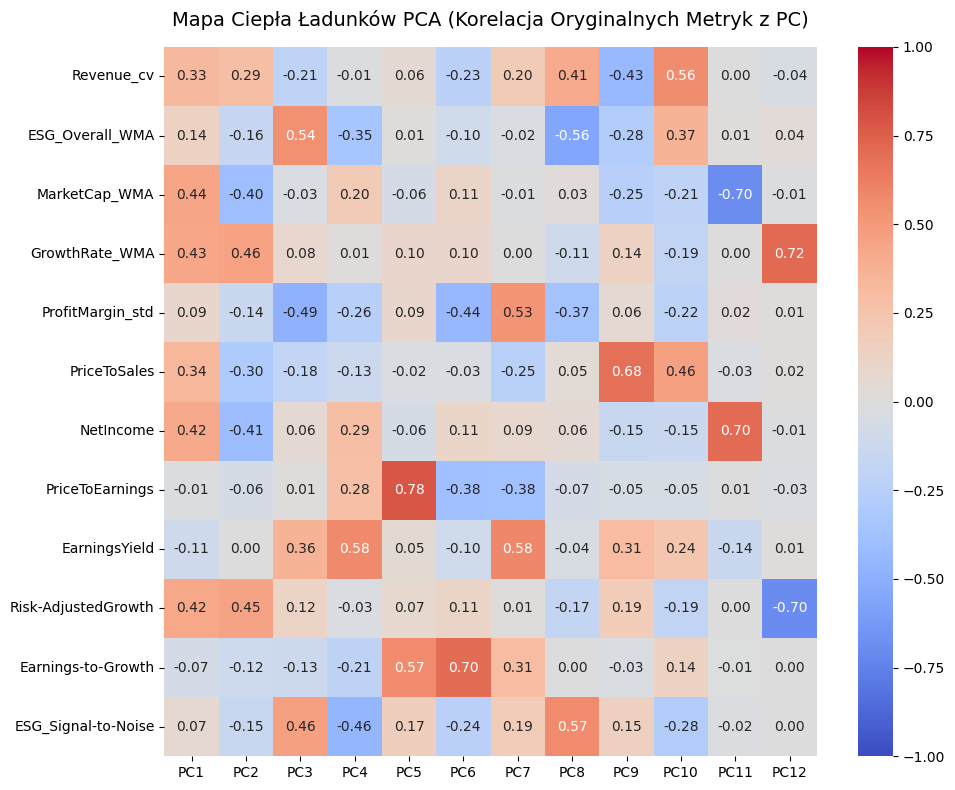

In [ ]:
num_components_to_analyze = len(explained_variance)

loadings = pd.DataFrame(
    pca.components_.T[:, :num_components_to_analyze], 
    columns=[f'PC{i+1}' for i in range(num_components_to_analyze)],
    index=X.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Mapa Ciepła Ładunków PCA (Korelacja Oryginalnych Metryk z PC)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### Najważniejszy loading dla każdej Składowej Głównej

In [16]:
pc_columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']

loadings = pd.DataFrame(
    pca.components_.T[:, :len(pc_columns)],
    columns = pc_columns,
    index = X.columns
)

print("=== SKŁADOWA PC1 ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC2 ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC3 ===")
print(loadings['PC3'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC4 ===")
print(loadings['PC4'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC5 ===")
print(loadings['PC5'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC6 ===")
print(loadings['PC6'].abs().sort_values(ascending=False).head(1))

=== SKŁADOWA PC1 ===
MarketCap_WMA    0.438314
Name: PC1, dtype: float64

=== SKŁADOWA PC2 ===
GrowthRate_WMA    0.460405
Name: PC2, dtype: float64

=== SKŁADOWA PC3 ===
ESG_Overall_WMA    0.542382
Name: PC3, dtype: float64

=== SKŁADOWA PC4 ===
EarningsYield    0.575464
Name: PC4, dtype: float64

=== SKŁADOWA PC5 ===
PriceToEarnings    0.783519
Name: PC5, dtype: float64

=== SKŁADOWA PC6 ===
Earnings-to-Growth    0.698653
Name: PC6, dtype: float64


### Krok 9: Wybór 3 metryk najlepiej oddających wariancję zbioru danych dla PC1-PC6
Ponowne użycie wzoru **PCA-based Feature Importance**
$$I_j = \sum_{i=1}^{k} \lambda_i |l_{i,j}|$$

In [17]:
weighted_metrics_importance = np.dot(pca.explained_variance_ratio_, np.abs(pca.components_))

metrics_importance_df = pd.DataFrame({
    'Metryka': X.columns,
    'Istotnosc_PCA': weighted_metrics_importance
}).sort_values(by='Istotnosc_PCA', ascending=False)

display(metrics_importance_df)

,Metryka,Istotnosc_PCA
0,Revenue_cv,0.252051
6,NetIncome,0.237808
11,ESG_Signal-to-Noise,0.237409
5,PriceToSales,0.236625
4,ProfitMargin_std,0.236334
9,Risk-AdjustedGrowth,0.230053
2,MarketCap_WMA,0.229644
1,ESG_Overall_WMA,0.227044
3,GrowthRate_WMA,0.220674
8,EarningsYield,0.208667


### W fuzzy_rules_27.ipynb zostały uzyte: 
`EarningsYield`, `Risk-AdjustedGrowth`, `ESG_Signal-to-Noise`
### W fuzzy_rules.ipynb zostały użyte: 
`Earnings-to-Growth`, `ESG_Signal-to-Noise`, `ProfitMargin_WMA`, `PriceTosales`
### Analiza Składników Głównych wytypowała:
`Revenue_cv`, `NetIncome`, `ESG_Signal-to-Noise`

*Należy zauważyć, że te metryki `Revenue` i `NetIncome` są ze sobą powiązane. `NetIncome` wyliczamy poprzez przemnożenie `Revenue_mean` i `ProfitMargin_mean`. Jednakże zaproponowana metryka to `Revenue_cv`, czyli współczynnik zmienności przychodów firmy*

## Krok 10: Następstwa i hipotezy

Porównanie dwóch fuzzy systems 

1) Na podstawie analizy eksperckiej danych (arbitralny dobór metryk)
2) Na podstawie Principal Component Analysis (dobór metryk dokonywany przez algorytm PCA)

Podejście **(2)** jest uniwersalne dla danych nie tylko finansowych. Zaproponowana metoda analizy i przetwarzania danych może być stosowana do danych:
- medycznych
- finansowych
- ekologicznych
- wsm wszystkich xD